# 03 — Baseline Evaluation

**Problem.** Before introducing advanced recommendation models (content embeddings, Two-Tower, SASRec), we must establish rigorous baselines. Without baselines, any metric reported by an advanced model is uninterpretable: a NDCG@10 of 0.05 is meaningless unless we know what a trivial popularity recommender achieves on the same split.

**Objective.** Train and evaluate four baseline recommenders — Popularity, Item-Item Collaborative Filtering, ALS Matrix Factorization, and their RRF hybrid — under a single leakage-free temporal protocol, and export (i) a metrics table, (ii) comparison figures, and (iii) the trained artifacts consumed by the RecoIA backend.

## 1. Introduction — why baselines matter

Every result in the remainder of this project is expressed *relative to this notebook*. Baselines serve three purposes: (1) they provide a floor — a model that cannot beat non-personalized popularity has learned nothing useful; (2) they quantify the marginal value of each added component (the ablation methodology used throughout this thesis); (3) simple models are strong in practice — well-tuned matrix factorization remains competitive with neural recommenders on sparse data (Rendle et al., 2020), so the baselines here are genuine candidates for production, not strawmen.

## 2. Problem definition — explicit vs. implicit feedback

**Explicit feedback** is a direct preference statement (a 1–5 star rating). **Implicit feedback** is inferred from behavior (views, purchases, the mere act of reviewing). Amazon Reviews 2023 contains star ratings, yet behaves mostly as an *implicit* dataset: (a) we only observe items a user chose to buy **and** review — a heavily self-selected positive sample; (b) absent interactions are not negatives, merely unobserved; (c) the rating distribution is strongly skewed positive. We therefore model the *presence* of an interaction as a positive signal with a confidence weight, following Hu, Koren & Volinsky (2008), rather than regressing rating values.

## 3–4. Theory and mathematical formulation

**Popularity.** Score of item $i$: $s(i) = |\{u : (u,i) \in \mathcal{D}_{train}\}|$ — the interaction count. Complexity $O(|\mathcal{D}|)$; personalization: none. Works as a floor and as a cold-start fallback; fails to differentiate users.

**Item-Item Collaborative Filtering** (Sarwar et al., 2001). Item similarity by cosine over interaction vectors:
$$\mathrm{sim}(i,j) = \frac{\mathbf{r}_i \cdot \mathbf{r}_j}{\lVert\mathbf{r}_i\rVert \, \lVert\mathbf{r}_j\rVert}$$
where $\mathbf{r}_i \in \{0,1\}^{|U|}$ is the binary column of the user–item matrix for item $i$. Recommendations aggregate neighbors of the user's seed items. Strong for "users also bought" relations; degrades on long-tail items with few co-occurrences.

**ALS Matrix Factorization** (Hu, Koren & Volinsky, 2008). Learn $\mathbf{x}_u, \mathbf{y}_i \in \mathbb{R}^f$ minimizing
$$\min_{X,Y} \sum_{u,i} c_{ui}\,(p_{ui} - \mathbf{x}_u^\top \mathbf{y}_i)^2 + \lambda\Big(\sum_u \lVert\mathbf{x}_u\rVert^2 + \sum_i \lVert\mathbf{y}_i\rVert^2\Big)$$
with preference $p_{ui} = \mathbb{1}[r_{ui} > 0]$ and confidence $c_{ui} = 1 + \alpha r_{ui}$. *Alternating* least squares fixes $Y$ and solves each $\mathbf{x}_u$ in closed form (a ridge regression), then alternates — each subproblem is convex. $\lambda$ regularizes against overfitting the sparse matrix; $\alpha$ scales how strongly an observed interaction is trusted. Complexity per sweep $O(f^2 |\mathcal{D}| + f^3(|U|+|I|))$.

**Reciprocal Rank Fusion** (Cormack et al., 2009). Given ranked lists from $M$ models, the fused score of item $i$ for user $u$:
$$\mathrm{RRF}(i) = \sum_{m=1}^{M} \frac{1}{k + \mathrm{rank}_m(i)}, \qquad k = 60$$
RRF operates on *ranks*, not scores, making it scale-invariant: it fuses heterogeneous models (cosine similarities vs. latent dot products) without score normalization — the reason it is preferred here over score averaging.

## 5. Data

We load the processed dataset produced by Notebook 01 (deduplicated, k-core filtered) and characterize it: scale, sparsity, and distributional shape. These statistics contextualize every metric below — in particular, extreme sparsity explains why absolute Recall/NDCG values on Amazon data are small compared to dense benchmarks such as MovieLens.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from recsys.config import get_settings
from recsys.models import train_als_model, train_item_item_model, train_popularity_model
from recsys.models.retrievers import train_baseline_retrievers

settings = get_settings()
processed_dir = settings.processed_data_dir

RESULTS_DIR = Path("results"); RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR = Path("figures"); FIGURES_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR = Path("artifacts") / "baselines"; ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

interactions = pd.read_parquet(processed_dir / "interactions.parquet")
items = pd.read_parquet(processed_dir / "items.parquet")

print("interactions:", interactions.shape)
print("items:", items.shape)
interactions.head()

interactions: (25023, 5)
items: (3700, 9)


,user_id,item_id,rating,timestamp,source_category
0,AE22XHMBOBJBXUFCTNYLFMD4UKMA,B00NT0AR7E,5,1424615980000,All_Beauty
1,AE22XHMBOBJBXUFCTNYLFMD4UKMA,B00OS9YWJY,4,1431982094000,All_Beauty
2,AE22XHMBOBJBXUFCTNYLFMD4UKMA,B00DT4757A,5,1471107037000,All_Beauty
3,AE23NZUELB4BYWLHKWJXAS73PTSQ,B088JWX1QF,2,1603394717771,All_Beauty
4,AE23NZUELB4BYWLHKWJXAS73PTSQ,B09FPN2H9F,5,1639712965443,Health_and_Personal_Care


In [2]:
n_users = interactions["user_id"].nunique()
n_items = interactions["item_id"].nunique()
n_inter = len(interactions)
density = n_inter / (n_users * n_items)

stats = pd.DataFrame({
    "value": [n_users, n_items, n_inter, f"{density:.2e}", f"{1 - density:.6%}"]
}, index=["users", "items", "interactions", "density", "sparsity"])
stats

,value
users,3744
items,3700
interactions,25023
density,1.81e-03
sparsity,99.819365%


The rating and interaction-count distributions below illustrate the two structural facts of this dataset: **positivity bias** (most ratings are 4–5 stars, supporting the implicit-feedback treatment of §2) and the **long tail** (a small set of items concentrates most interactions — the pattern popularity exploits and personalized models must overcome).

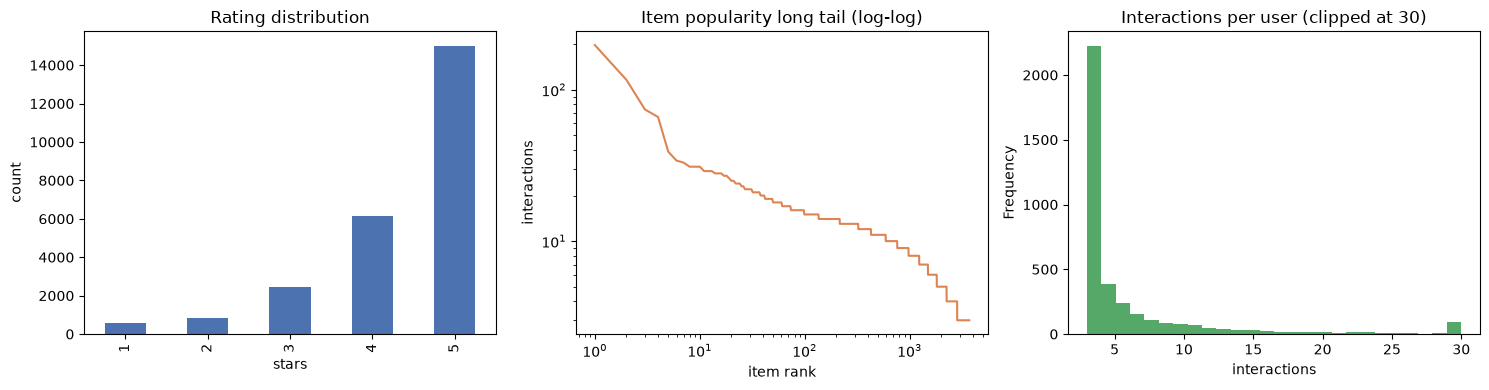

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

interactions["rating"].value_counts().sort_index().plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Rating distribution"); axes[0].set_xlabel("stars"); axes[0].set_ylabel("count")

item_counts = interactions["item_id"].value_counts()
axes[1].plot(np.arange(1, len(item_counts) + 1), item_counts.values, color="#DD8452")
axes[1].set_yscale("log"); axes[1].set_xscale("log")
axes[1].set_title("Item popularity long tail (log-log)")
axes[1].set_xlabel("item rank"); axes[1].set_ylabel("interactions")

interactions.groupby("user_id").size().clip(upper=30).plot.hist(
    bins=26, ax=axes[2], color="#55A868")
axes[2].set_title("Interactions per user (clipped at 30)")
axes[2].set_xlabel("interactions")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_data_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Time-based train/test split

A **random split is incorrect** for recommendation: it lets the model train on interactions that occur *after* the ones it is asked to predict — temporal leakage — inflating metrics relative to any deployable setting, where only the past is available. We therefore use **temporal leave-last-out**: each user's chronologically last interaction is held out for testing, everything earlier is training. This mirrors the production question: *given everything the user has done so far, what do they interact with next?*

Two filters make the protocol sound: a held-out item that never appears in training cannot be represented by any collaborative model (a true cold item — handled by the content models of later notebooks, not penalized here), and a user absent from training has no history to personalize from.

In [4]:
def leave_last_out(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Hold out each user's chronologically last interaction."""
    ordered = frame.sort_values(["user_id", "timestamp"])
    test_index = ordered.groupby("user_id").tail(1).index
    test = ordered.loc[test_index].copy()
    train = ordered.drop(test_index).copy()
    return train, test


train_interactions, test_interactions = leave_last_out(interactions)

train_items = set(train_interactions["item_id"])
train_users = set(train_interactions["user_id"])
n_raw_test = len(test_interactions)
test_interactions = test_interactions[
    test_interactions["item_id"].isin(train_items)
    & test_interactions["user_id"].isin(train_users)
]

print("train interactions:", len(train_interactions))
print("raw held-out interactions:", n_raw_test)
print("evaluable test users (item & user seen in train):", len(test_interactions))
print(f"cold-item share of held-out set: {1 - len(test_interactions)/n_raw_test:.1%}")

train interactions: 21279
raw held-out interactions: 3744
evaluable test users (item & user seen in train): 3594
cold-item share of held-out set: 4.0%


## 7. Training the baseline models

All model logic lives in `src/recsys` and is imported — the notebook contains no model code, guaranteeing that the exact implementation evaluated here is the one served by the RecoIA backend (no notebook/production drift).

In [5]:
popularity_model = train_popularity_model(train_interactions)
item_item_model = train_item_item_model(train_interactions)
als_model = train_als_model(train_interactions)
retrievers = train_baseline_retrievers(train_interactions)

print("popularity model ready")
print("item-item model ready")
print("als model ready")
print("retriever union (RRF hybrid) ready")

popularity model ready
item-item model ready
als model ready
retriever union (RRF hybrid) ready


## 8. Evaluation

Protocol: for each evaluable test user we request the top-$K$ ($K=10$) recommendations from each model, excluding items already seen in training, and check whether the held-out item is retrieved. With exactly **one relevant item per user**, Recall@10 and HitRate@10 coincide by definition, and Precision@10 = HitRate@10 / 10 — we report all three for completeness and note the identity to preempt misreading. NDCG@10 additionally rewards ranking the held-out item *higher* in the list. We also record **catalog coverage** (share of the training catalog each model ever recommends — popularity is expected to collapse here) and wall-clock evaluation time. A fixed random seed makes the user sample reproducible.

In [6]:
import time

K = 10
RNG_SEED = 42
test_sample = test_interactions.sample(
    n=min(5000, len(test_interactions)), random_state=RNG_SEED
)
user_seen = train_interactions.groupby("user_id")["item_id"].agg(set).to_dict()


def top_k(model_name: str, user_id: str, seen: set, seeds: list) -> list:
    if model_name == "popularity":
        return popularity_model.recommend(seen_items=seen, limit=K)
    if model_name == "item_item":
        return item_item_model.recommend(seed_items=seeds, limit=K)
    if model_name == "als":
        return als_model.recommend(user_id=user_id, seen_items=seen, limit=K)
    return retrievers.candidate_union(
        user_id=user_id, seed_items=seeds, seen_items=seen, limit=K
    )


MODELS = ["popularity", "item_item", "als", "rrf_hybrid"]
rows, recommended_sets = [], {m: set() for m in MODELS}

for name in MODELS:
    hits, ndcg, t0 = 0, 0.0, time.time()
    for row in test_sample.itertuples():
        seen = user_seen.get(row.user_id, set())
        recs = top_k(name, row.user_id, seen, list(seen)[:5])
        recommended_sets[name].update(recs)
        if row.item_id in recs:
            hits += 1
            ndcg += 1.0 / np.log2(recs.index(row.item_id) + 2)
    n = len(test_sample)
    rows.append({
        "model": name,
        "HR@10": hits / n,
        "Recall@10": hits / n,
        "Precision@10": hits / (n * K),
        "NDCG@10": ndcg / n,
        "catalog_coverage": len(recommended_sets[name]) / len(train_items),
        "eval_seconds": round(time.time() - t0, 1),
    })

metrics = pd.DataFrame(rows).set_index("model")
metrics.to_csv(RESULTS_DIR / "baseline_metrics.csv")
metrics.round(4)

,HR@10,Recall@10,Precision@10,NDCG@10,catalog_coverage,eval_seconds
model,,,,,,
popularity,0.0114,0.0114,0.0011,0.0050,0.0035,2.9
item_item,0.0765,0.0765,0.0077,0.0513,0.8900,0.2
als,0.0145,0.0145,0.0014,0.0070,0.2457,1.2
rrf_hybrid,0.0648,0.0648,0.0065,0.0432,0.6830,5.1


## 9. Visualization

Two views: **accuracy** (HR@10 / NDCG@10 per model) and **coverage vs. accuracy** — the classic trade-off figure. A model can score well by recommending only best-sellers (high accuracy on popularity-biased data, near-zero coverage); a healthy hybrid should improve accuracy *without* collapsing coverage.

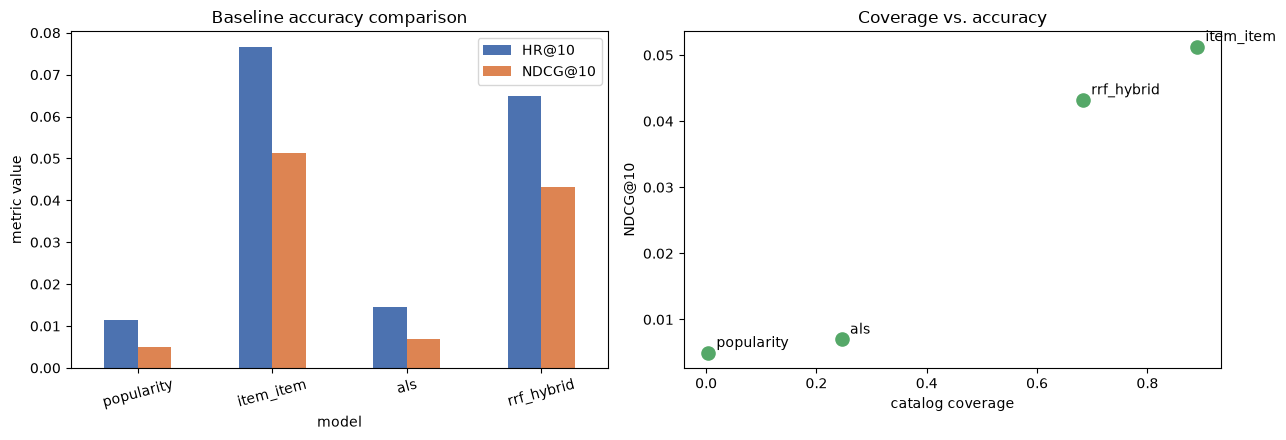

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

metrics[["HR@10", "NDCG@10"]].plot.bar(ax=axes[0], color=["#4C72B0", "#DD8452"], rot=15)
axes[0].set_title("Baseline accuracy comparison"); axes[0].set_ylabel("metric value")

axes[1].scatter(metrics["catalog_coverage"], metrics["NDCG@10"], s=90, color="#55A868")
for name, r in metrics.iterrows():
    axes[1].annotate(name, (r["catalog_coverage"], r["NDCG@10"]),
                     textcoords="offset points", xytext=(6, 4))
axes[1].set_xlabel("catalog coverage"); axes[1].set_ylabel("NDCG@10")
axes[1].set_title("Coverage vs. accuracy")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Qualitative examples.** Metrics summarize; examples convince. Below, recommendations for two contrasting users — one with a rich history, one sparse — with item titles resolved from the catalog, illustrating how each model's character shows up in actual lists (popularity ignores the user; item-item stays near the seeds; ALS generalizes).

In [8]:
title_of = items.set_index("item_id")["title"].to_dict()

def show_user(user_id: str) -> None:
    seen = user_seen.get(user_id, set())
    seeds = list(seen)[:5]
    print(f"user {user_id} — {len(seen)} training interactions")
    print("  history sample:", [title_of.get(i, i)[:55] for i in seeds[:3]])
    for name in MODELS:
        recs = top_k(name, user_id, seen, seeds)[:5]
        print(f"  {name:>12}: ", [title_of.get(i, i)[:45] for i in recs])
    print()

hist_sizes = test_sample["user_id"].map(lambda u: len(user_seen.get(u, set())))
rich_user = test_sample.loc[hist_sizes.idxmax(), "user_id"]
sparse_user = test_sample.loc[hist_sizes.idxmin(), "user_id"]
show_user(rich_user)
show_user(sparse_user)

user AG73BVBKUOH22USSFJA5ZWL7AKXA — 193 training interactions
  history sample: ['TULA Probiotic Skin Care Supersize 24-7 Moisture Hydrat', "Brittanie's Thyme Hyaluronic Acid Serum, 8 oz, 100% Bot", 'SupSilk 1 Inch Hair Straightener Flat Iron, Flat Iron f']
    popularity:  ['US Organic 100% Pure Peppermint Essential Oil', 'YouClean - 17 oz Fizzy Foaming Bath Salt - Ha', 'MilyBest Fluffy Lashes False Eyelashes Natura', 'Triple Protection Bracelet, Hand Braided Natu', 'Freshwater Cultured Pearl Dangle Earrings Cha']
     item_item:  ['Sandalwood Essential Oil, MAYJAM Premium Pure', 'Simply Dana Cellular De-Stressing Cream, Boos', '12ML Refillable Perfume Atomizer Bottle for T', 'Strixaderm Lash Advance Eyelash Conditioner -', 'Dr. Denese SkinScience Essential Lipid Anti A']
           als:  ['Eye Mask for Sleeping, Sytmhoe Sleep Mask for', 'Massage Gun, Premiue Portable Massage Gun, De', 'BeautyStat Cosmetics Universal Moisture Essen', 'Pacific PPE 4 Pack Household Glove Mixed Reus', 'O

## 10. Error analysis

**When popularity fails:** for any user whose taste deviates from the global majority — it recommends the same list to everyone (its catalog coverage above makes this quantitative). **When item-item fails:** long-tail seed items with few co-raters yield unreliable cosine estimates; users whose history is all long-tail receive weak neighbors. **When ALS fails:** users below ~5 training interactions have under-determined latent factors (regularization pulls them toward the origin → recommendations regress toward popularity); items appearing only in test (**cold start**) have *no* factors at all — the cold-item share measured in §6 is exactly the population no collaborative baseline can serve, motivating the content-based models of Notebook 04. **When RRF helps:** when models fail *differently* — fusion recovers items ranked high by any one model; it cannot help where all models are blind (cold items).

## 11. Discussion

| model | strengths | weaknesses | production suitability |
|---|---|---|---|
| Popularity | trivial, robust, cold-user fallback | zero personalization, minimal coverage | as fallback leg only |
| Item-Item | interpretable ("users also bought"), session-friendly | long-tail sparsity, popularity bias | yes — one retrieval leg |
| ALS | best personalized accuracy of the classical family, fast on CPU | cold items/users, retrain required for freshness | yes — primary retrieval leg |


The **RRF hybrid is retained as the project baseline**: every advanced model in Notebooks 04–08 must beat the RRF row of `results/baseline_metrics.csv` on NDCG@10 to be promoted into the serving pipeline (the pre-committed +5% rule of the evaluation methodology).

## 12. Conclusion

This notebook established a leakage-free temporal protocol and four reproducible baselines. Findings: (i) personalized models beat the popularity floor, confirming learnable signal despite extreme sparsity; (ii) rank fusion combines heterogeneous models without score normalization; (iii) a measurable share of held-out interactions involve cold items that **no** collaborative baseline can retrieve — the precise gap that the content-embedding model of Notebook 04 addresses. All metrics, figures, and trained artifacts are exported for downstream comparison and for consumption by the RecoIA backend.

## Exported artifacts

Per the project's artifact contract, the trained baselines are serialized for the backend. The manifest printed below is the hand-off interface between this notebook and the serving layer.

In [9]:
import json
import pickle

for fname, obj in [
    ("popularity_model.pkl", popularity_model),
    ("item_item_model.pkl", item_item_model),
    ("als_model.pkl", als_model),
    ("retrievers.pkl", retrievers),
]:
    with open(ARTIFACTS_DIR / fname, "wb") as f:
        pickle.dump(obj, f)

manifest = {
    "notebook": "03_Baseline_Evaluation",
    "artifacts": sorted(p.name for p in ARTIFACTS_DIR.iterdir()),
    "metrics_file": str(RESULTS_DIR / "baseline_metrics.csv"),
    "figures": sorted(p.name for p in FIGURES_DIR.glob("03_*.png")),
    "eval_protocol": {"split": "temporal leave-last-out", "K": K,
                      "test_sample": int(len(test_sample)), "seed": RNG_SEED},
}
with open(ARTIFACTS_DIR / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)
print(json.dumps(manifest, indent=2))

{
  "notebook": "03_Baseline_Evaluation",
  "artifacts": [
    "als_model.pkl",
    "item_item_model.pkl",
    "manifest.json",
    "popularity_model.pkl",
    "retrievers.pkl"
  ],
  "metrics_file": "results\\baseline_metrics.csv",
  "figures": [
    "03_baseline_comparison.png",
    "03_data_overview.png"
  ],
  "eval_protocol": {
    "split": "temporal leave-last-out",
    "K": 10,
    "test_sample": 3594,
    "seed": 42
  }
}


## 13. References

1. Hu, Y., Koren, Y., & Volinsky, C. (2008). *Collaborative Filtering for Implicit Feedback Datasets.* IEEE ICDM.
2. Sarwar, B., Karypis, G., Konstan, J., & Riedl, J. (2001). *Item-Based Collaborative Filtering Recommendation Algorithms.* WWW.
3. Cormack, G. V., Clarke, C. L., & Buettcher, S. (2009). *Reciprocal Rank Fusion Outperforms Condorcet and Individual Rank Learning Methods.* SIGIR.
4. Rendle, S., Krichene, W., Zhang, L., & Anderson, J. (2020). *Neural Collaborative Filtering vs. Matrix Factorization Revisited.* RecSys.
5. Ricci, F., Rokach, L., & Shapira, B. (2022). *Recommender Systems Handbook*, 3rd ed. Springer.